In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

<font size="6" color="red">ch10. N차원 배열 다루기</font>
- N차원 배열 객체 : 동일 자료형의 집합
- 2차원 배열은 행렬개념으로 이해
- [numpy](https://numpy.org)
- [numpy API Docs](https://numpy.org/doc/stable/reference/index.html)
# 1절. 넘파이 패키지

In [4]:
import numpy as np
np.__version__ # tensorflow==2.10과 맞는 numpy 버전

'1.23.5'

In [7]:
# np.arange(from,stop, by) : from부터 stop앞까지 by씩 증가하는 1차원 정수 배열
a = np.arange(15)
print(a.shape) # 15열짜리 1차원 배열
a

(15,)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

## 1.1 배열속성

In [55]:
from numpy import arange
a = arange(15, 
          # dtype=np.int8
          ).reshape(3, 5) #3행5열짜리로 변환
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14]])

In [24]:
type(a) # a변수의 타입

numpy.ndarray

In [26]:
a.dtype # a배열의 요소(item)들의 type

dtype('int32')

In [32]:
a.dtype.name

'int32'

In [33]:
a.itemsize # 한 요소(item)의 bytesize

4

In [38]:
a.ndim # 축수(차원수)

2

In [40]:
a.size # 배열 요소의 갯수

15

In [27]:
a.shape # 배열 구조(2차원 3행5열)

(3, 5)

In [56]:
print('shape 조정전 a:\n', a)
a.shape = (5,3)
print('shape 조정후 a:\n', a)

shape 조정전 a:
 [[ 0  1  2  3  4]
 [ 5  6  7  8  9]
 [10 11 12 13 14]]
shape 조정후 a:
 [[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]
 [12 13 14]]


## 1.2 배열 타입 변경

In [57]:
# 배열 요소의 타입변경(X)
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [58]:
a.size # 요소갯수

12

In [59]:
a.dtype 

dtype('int32')

In [60]:
a.itemsize

4

In [61]:
a.dtype = np.int64
a.dtype

dtype('int64')

In [62]:
a.itemsize # 요소의 byte수

8

In [54]:
a

array([[ 4294967296, 12884901890],
       [21474836484, 30064771078],
       [38654705672, 47244640266]], dtype=int64)

In [63]:
a.size # 요소수

6

In [64]:
# 배열 요소의 타입변경(O)
a = arange(15).reshape(5,3)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]])

In [68]:
#a.astype(np.int64) # 출력O->a가 바뀌지 않음. 출력X->a바뀜
a = a.astype(np.int64)
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [69]:
a.dtype

dtype('int64')

In [71]:
a.itemsize

8

In [72]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [75]:
a.ravel() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

In [76]:
a.flatten() # flaten된 배열을 return

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14],
      dtype=int64)

## 1.3 배열 저장
- pkl(객체, 배열, 머신러닝 모델 저장) vs npy(넘파이 전용포맷, io개선)

In [78]:
a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [85]:
%%time
import time
start = time.time() # 1970.1.1부터 지금까지의 초수
import pickle
with open('data/ch10.pkl', 'wb') as f:
    pickle.dump(a, f)
end = time.time()
print('실행 시간 :', (end-start))

실행 시간 : 0.0
CPU times: total: 0 ns
Wall time: 0 ns


In [86]:
%%time
with open('data/ch10.pkl', 'rb') as f:
    loaded_a = pickle.load(f)

CPU times: total: 0 ns
Wall time: 2.04 ms


In [84]:
# a ==(파일저장)==> 피클파일(269B) ==(load)==> loaded_a
loaded_a

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

In [87]:
%%time
np.save('data/ch11.npy', a) #넘파이전용포맷. 빠르고 효율적 안전

CPU times: total: 0 ns
Wall time: 1.02 ms


In [88]:
%%time
loaded_a2 = np.load('data/ch11.npy')

CPU times: total: 0 ns
Wall time: 9.14 ms


In [89]:
# a ==(저장)==> npy(248B) ==(load)==> loaded_a2
loaded_a2

array([[ 0,  1,  2],
       [ 3,  4,  5],
       [ 6,  7,  8],
       [ 9, 10, 11],
       [12, 13, 14]], dtype=int64)

# 2절. 넘파이배열
- array()함수를 이용한 다른 파이썬 데이터구조(list, tup)를 배열변환
- 특정값을 갖는 배열 생성함수 : arange, ones, zeros, full, empty.....
- 랜덤값을 갖는 배열 생성함수 ....
- [넘파이함수들](https://numpy.org/doc/stable/reference/index.html)
## 2.1 array()함수로 넘파이 배열 만들기
- array(obj, dtype=np.type, copy=T/F)
- array(obj, dtype='type', copy=T/F)
type 예 : int16, int32, float16, float32, float64,...

In [91]:
a = np.array([2, 14, 6],
             # dtype=np.int16
            ) # 정수의 기본 타입은 int32/실수의 기본타입은 float64
a, a.dtype

(array([ 2, 14,  6]), dtype('int32'))

In [92]:
a[0], a[1], a[2]

(2, 14, 6)

In [93]:
for item in a:
    print(item, end='\t')

2	14	6	

In [96]:
b = np.array([[1.5, 2.3],  # 동일자료형의 집합으로 배열 생성 : 정수>실수>문자
              [4, 5]])     # 실수 배열의 기본타입 : float64
b

array([[1.5, 2.3],
       [4. , 5. ]])

In [97]:
b.dtype

dtype('float64')

In [98]:
l = [[1.5, 2.3],[4, 5]]
l[0][1]

2.3

In [99]:
b[0,1] # 2차원 [axis0=행, axis1=열]  cf. 1차원[axis0=열]

2.3

In [110]:
a = np.array([[1.5, 2.3], 
              [4,5]], 
            # dtype="float32"
             dtype=np.float32
            ).reshape(4)
a

array([1.5, 2.3, 4. , 5. ], dtype=float32)

In [111]:
a.dtype

dtype('float32')

In [112]:
# a의 배열 구조 변경
a.shape = (2,2)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float32)

In [114]:
# a의 dtype(요소의 타입) 변경
# a.dtype = np.float16
a = a.astype(np.float16)
a

array([[1.5, 2.3],
       [4. , 5. ]], dtype=float16)

In [116]:
l = [[1.5, 2.3], 
     [4,5]]
for row in l:
    for item in row:
        print(item, end=' ')
    print()

1.5 2.3 
4 5 


In [119]:
for i, row in enumerate(l):
    for j, item in enumerate(row):
        print(f"{i}행{j}열 : {l[i][j]}", end='\t')
    print()

0행0열 : 1.5	0행1열 : 2.3	
1행0열 : 4	1행1열 : 5	


In [120]:
for row in a:
    for item in row:
        print(item, end=' ')
    print()

1.5 2.3 
4.0 5.0 


In [122]:
for i, row in enumerate(a):
    for j, item in enumerate(row):
        #print(f"{i}행{j}열 : {a[i][j]}", end='\t')
        print(f"{i}행{j}열 : {a[i,j]}", end='\t') # float16은 소숫점이하가 불안정
    print()

0행0열 : 1.5	0행1열 : 2.30078125	
1행0열 : 4.0	1행1열 : 5.0	


In [126]:
print(b[0,-1]) # 인덱싱
# print(b[0,2]) 없는 인덱싱은 에러

2.3


In [131]:
# 슬라이싱 from:stop:by : from부터 stop전까지 by씩 전진. 인덱싱은 음수
b[0:, 1:10] # 0~끝행, 1열부터10전열까지 슬라이싱(행과 열 모두 슬라이싱 2차원 배열)

array([[2.3],
       [5. ]])

In [133]:
b[0, 1:3] # 0행,1열부터3열전까지 슬라이싱(열만 슬라이싱 1차원 배열)

array([2.3])

In [139]:
b = np.array([[1, 2, 3],
              [6, 7, 8]])
# 모든 행의 마지막 열만 추출
b[:, -1:], b[:, -1]

(array([[3],
        [8]]),
 array([3, 8]))

In [141]:
# 모든 행의 마지막 열을 제외한 부분 추출
b[:, :-1]

array([[1, 2],
       [6, 7]])

In [143]:
# 스칼라 변수
a = 10  # 원본
b = a   # 복제본
print("a={}, b={}, a주소={}, b주소={}".format(a, b, id(a), id(b)))
b = -1
print("a={}, b={}, a주소={}, b주소={}".format(a, b, id(a), id(b)))

a=10, b=10, a주소=1883862860304, b주소=1883862860304
a=10, b=-1, a주소=1883862860304, b주소=1883862859952


In [158]:
# numpy 배열
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=False) # d = c 동일 #할당
print("c=", c, sep="\n")
print("d=", c, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0, 0] = 9
print("c=", d, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 1884005143664 1884005143664
c=
[[9 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 1884005143664 1884005143664


In [160]:
# numpy 배열
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=True) # d = c.copy()와 동일 #깊은 복사
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0,0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 1884005147984 1884005139152
9
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 1884005147984 1884005139152


In [162]:
# copy=False해도 깊은 복사가 되는 경우 : dtype이 바뀌면 자동 깊은 복사
c = np.array([[1, 2], [3, 4]], dtype=np.int8) # 원본
d = np.array(c, copy=False,    dtype=np.int32)
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))
d[0,0] = 9
print("c=", c, sep="\n")
print("d=", d, sep="\n")
print('두 변수의 주소 :', id(c), id(d))

c=
[[1 2]
 [3 4]]
d=
[[1 2]
 [3 4]]
두 변수의 주소 : 1884005143568 1884005143184
c=
[[1 2]
 [3 4]]
d=
[[9 2]
 [3 4]]
두 변수의 주소 : 1884005143568 1884005143184


## 2.2 기본값이 있는 배열 만들기
- np.zeros( tup [,dtype] ) : 요소들이 다 0.0
- np.ones( tup [,dtype] ) : 요소들이 다 1.0
- np.full(tup, 기본값) : 요소들이 다 두번째 매개변수인 기본값
- np.empty( tup ) : 초기 내용은 임의의 값인 배열(메모리 상태에 따라 달라짐)

※ 위의 함수를 이용해서 생성된 배열은 기본 dtype이 float64. dtype속성을 따로 지정할 수 있음

In [231]:
np.zeros( (3, 5) ) # 3행5열짜리 2차원 float64 배열(요소들은 다 0)
np.zeros( (5,)   ) # 5열짜리 1차원 float64 배열(요소들은 다 0)
np.zeros( 5 ) # 5열짜리 1차원 float64 배열(요소들은 다 0)

array([0., 0., 0., 0., 0.])

In [234]:
x = np.zeros( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[False False False False False]
 [False False False False False]]
bool
1


In [236]:
np.ones( (3, 5) ) # 3행5열짜리 2차원 float64 배열(요소들은 다 1)
np.ones( (5,)   ) # 5열짜리 1차원 float64 배열(요소들은 다 1)
np.ones( 5 ) # 5열짜리 1차원 float64 배열(요소들은 다 1)

array([1., 1., 1., 1., 1.])

In [237]:
x = np.ones( (2, 5), dtype=np.bool8)
print(x)
print(x.dtype)
print(x.itemsize)

[[ True  True  True  True  True]
 [ True  True  True  True  True]]
bool
1


In [241]:
x = np.full( (2,5), 255 )
print(x)
print(x.dtype)

[[255 255 255 255 255]
 [255 255 255 255 255]]
int32


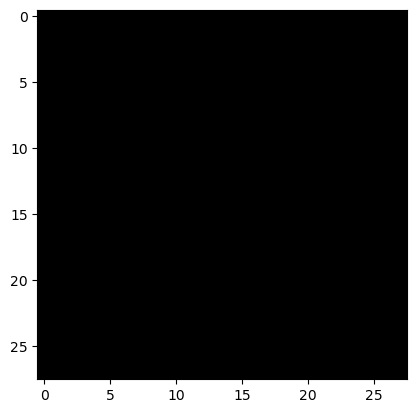

In [261]:
import matplotlib.pyplot as plt
img = np.full( (28,28), 255, dtype=np.uint8) # 하얀색
img = np.full( (28,28), 200, dtype=np.uint8) # 회색
img = np.zeros( (28,28), dtype=np.uint8) # 검정색
#plt.figure(figsize=(1,1))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
# plt.axis('off')
plt.show()

In [1]:
import numpy as np
np.empty( (3, 2) )

array([[2.44770517e-307, 1.61324815e-307],
       [9.34609790e-307, 4.45036841e-308],
       [1.11261095e-306, 1.22381779e-307]])

## 2.3 랜덤값을 갖는 배열 만들기
※ n차원 배열 만들기
- np.random.random( tup ) : 0부터 1미만의 균등분포를 갖은 tup 사이즈 랜덤값
- np.random.uniform(low=0, high=1.0, size=tup) : low부터 high미만까지 균등분포를 갖는 랜덤값
- np.random.normal(loc=0.0, scale=1.0, size=tup) : 평균loc, 표준편차scale을 갖는 정규분포 랜덤값
---
※ 1차원 배열 만들기
- np.random.rand(n) : 균등분포의 1차원 0~1미만 난수 배열 발생(난수가 n개)
- np.random.randn(n) : 표준정규분포(평균0, 표준편차가1인 정규분포)의 1차원 난수 배열 발생(난수 n개)
---
※ 난수 1개 만들기
- np.random.randint(n) : 0부터 n미만의 정수 난수 1개발생 == random.randint(0, n-1)
- np.random.randint(from, to) : from부터 to미만의 정수 난수 1개발생 
                    == random.randint(from,to-1)

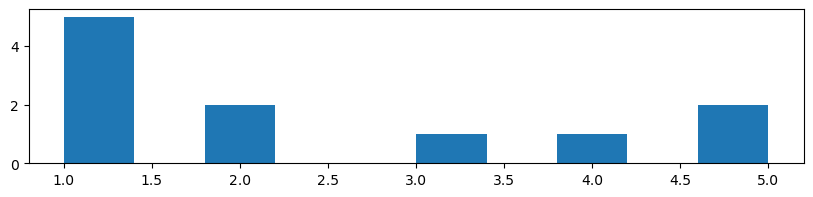

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = [1, 2, 3, 1, 1, 1, 2, 1, 4, 5, 5]
plt.hist(x, bins=10)
plt.show()

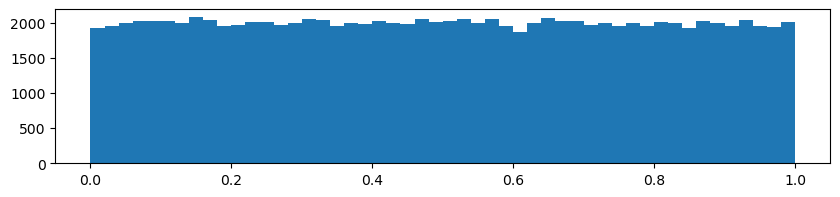

In [49]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
# x = np.random.random(1000000)
# x = np.random.uniform(1, 10, 10000000)
x = np.random.rand(100000)
plt.hist(x, bins=50)
plt.show()

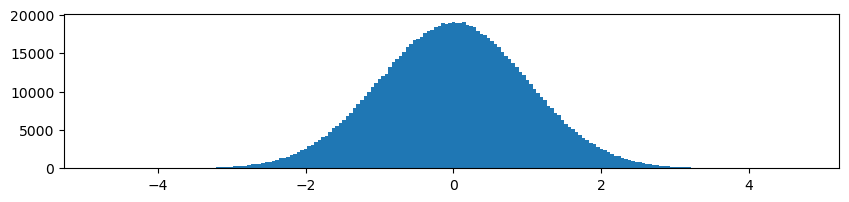

In [63]:
plt.figure(figsize=(10, 2)) # 그래프 사이즈 조절
x = np.random.normal(50, 10, 1000000) # 정규분포
x = np.random.normal(0, 1, 1000000) # 표준정규분포
x = np.random.randn(1000000)# 표준정규분포
plt.hist(x, bins=200)
plt.show()

In [26]:
# 2차원 균등분포 난수(0~1미만 실수 난수) 배열
import numpy as np
# np.random.seed(3) seed값을 맞추면 발생되는 난수가 동일. seed값을 초기화하려면 커널 재시작
np.random.random( (2, 5) ) # 2행5열짜리 2차원 난수 배열

array([[0.3370094 , 0.3903948 , 0.11415998, 0.65442309, 0.83737254],
       [0.2905231 , 0.30650276, 0.09498916, 0.64406314, 0.32549065]])

In [6]:
# 2차원 균등분포 난수(-1~1미만 실수 난수) 배열
np.random.uniform(-1, 1,  (2,5)) # 2행5열 2차원 배열

array([[-0.86034518,  0.93136066, -0.89236079, -0.68379059,  0.08561496],
       [ 0.80400007, -0.25638613, -0.90653428,  0.38276148, -0.92747447]])

In [22]:
# 2차원 정규분포 난수(평균 3에 표준편차1인 난수) 배열
x = np.random.normal(3, 1, size=(1, 5) ) # 1행 5열 2차원 배열
x

array([[3.48465547, 1.17193089, 4.22233261, 2.89126833, 3.40073519]])

In [28]:
# 1차원 균등분포 난수 배열
np.random.rand(3)
np.random.random(3)

array([0.3445485 , 0.52508885, 0.64249963])

In [32]:
# 1차원 표준정규분포(평균 0, 표준편차1인 정규분포) 배열
np.random.randn(3)
np.random.normal(size=3)

array([-0.34851787,  0.16654734, -1.42822661])

## 2.4 연속된 값을 갖는 배열 만들기
- np.arange(from, to, by, dtype) : from부터 to(to가 정수일 경우 to 미포함)앞까지 by씩 건너뛴 값을 1차원 배열로 생성
- np.linspace(from, to, num) : from부터 to(to 포함)까지 num개 숫자들을 1차원 배열로 생성

In [39]:
np.arange(10, 30, 5, dtype=np.float32)

array([10., 15., 20., 25.], dtype=float32)

In [43]:
np.arange(0, 3, 0.3)

array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7])

In [46]:
np.linspace(0, 3, 20) #0부터 3까지 같은 간격으로 20개 수를 배열

array([0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895,
       0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263,
       1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632,
       2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ])

In [47]:
np.linspace(0, 3, 20).reshape(4,5)

array([[0.        , 0.15789474, 0.31578947, 0.47368421, 0.63157895],
       [0.78947368, 0.94736842, 1.10526316, 1.26315789, 1.42105263],
       [1.57894737, 1.73684211, 1.89473684, 2.05263158, 2.21052632],
       [2.36842105, 2.52631579, 2.68421053, 2.84210526, 3.        ]])

In [56]:
x = np.array([0, 1, 2, 3, 4, 5, 6])
# linspace : 특정 구간에 많은 수의 점을 생성할 때 유용
x = np.linspace(0, 6, 200)
y = np.sin(x)

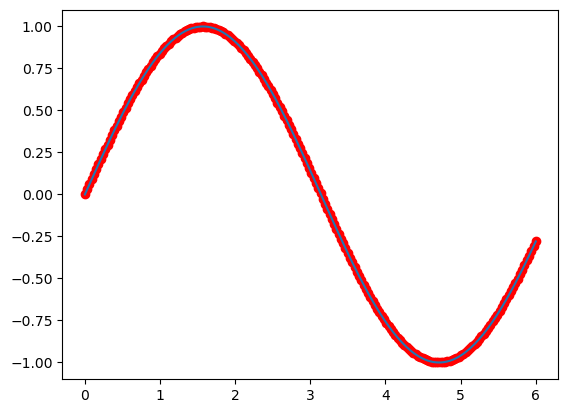

In [55]:
# import matplotlib.pyplot as plt
from matplotlib import pyplot as plt
plt.scatter(x, y, c='r') # 빨간색 점그래프
plt.plot(x, y) # 선그래프
plt.show()

## 2.5 배열의 차원 변경
- reshape(행수, 열수) : -1 가능
- resize( (행수,열수) ) : -1 불가
- ravel(), flatten() : 1차원으로 변환
- T : 전치행렬로 변환
- transpose() : 전치행렬로 변환

※ 실행결과가 출력되면 배열이 수정되지 않고, 실행결과가 없으면 배열이 수정됨

In [62]:
t = np.random.random( (2,5) )
print(t)
print(t*10)

[[0.120274   0.88224247 0.01111102 0.5278673  0.13283707]
 [0.92955472 0.93698653 0.72141902 0.99193084 0.45479566]]
[[1.20273999 8.8224247  0.11111019 5.27867297 1.32837067]
 [9.29554716 9.36986533 7.21419017 9.9193084  4.54795664]]


In [63]:
# t * 10 요소별 연산
# round(t*10) : 스칼라 값을 반올림
a = np.round(t*10)
a

array([[ 1.,  9.,  0.,  5.,  1.],
       [ 9.,  9.,  7., 10.,  5.]])

In [65]:
a = a.astype(np.int16) # astype()을 이용한 요소별 타입 변환
a # 2행5열

array([[ 1,  9,  0,  5,  1],
       [ 9,  9,  7, 10,  5]], dtype=int16)

In [66]:
a.reshape(5,2)

array([[ 1,  9],
       [ 0,  5],
       [ 1,  9],
       [ 9,  7],
       [10,  5]], dtype=int16)

In [68]:
a.reshape(5,-1) # -1이 주어지면 해당 차원의 크기가 자동 계산 a의 item이 10니 5행으로 하면 2열로 자동 계산

array([[ 1,  9],
       [ 0,  5],
       [ 1,  9],
       [ 9,  7],
       [10,  5]], dtype=int16)

In [71]:
a = a.reshape(-1, 2)
a

array([[ 1,  9],
       [ 0,  5],
       [ 1,  9],
       [ 9,  7],
       [10,  5]], dtype=int16)

In [76]:
a.resize( (2, 5) ) # a를 바꿈
a.resize(2, 5)
a

array([[ 1,  9,  0,  5,  1],
       [ 9,  9,  7, 10,  5]], dtype=int16)

In [77]:
# a.resize(-1) # resize함수에는 -1 불가

In [79]:
a.ravel()

array([ 1,  9,  0,  5,  1,  9,  9,  7, 10,  5], dtype=int16)

In [81]:
a.flatten()

array([ 1,  9,  0,  5,  1,  9,  9,  7, 10,  5], dtype=int16)

In [82]:
a

array([[ 1,  9,  0,  5,  1],
       [ 9,  9,  7, 10,  5]], dtype=int16)

In [83]:
a.T # a의 전치행렬(행과 열을 뒤바꾼 행렬 ex.0행1열->1행0열)

array([[ 1,  9],
       [ 9,  9],
       [ 0,  7],
       [ 5, 10],
       [ 1,  5]], dtype=int16)

In [84]:
a.transpose() # a의 전치행렬

array([[ 1,  9],
       [ 9,  9],
       [ 0,  7],
       [ 5, 10],
       [ 1,  5]], dtype=int16)

In [85]:
a

array([[ 1,  9,  0,  5,  1],
       [ 9,  9,  7, 10,  5]], dtype=int16)

## 2.6 배열 인쇄

In [93]:
print(np.arange(1001)) # item 갯수가 1000개까지만 나와. 배열이 너무 크면 안 나옴

[   0    1    2 ...  998  999 1000]


In [100]:
np.arange(10000).reshape(100, 100)

array([[   0,    1,    2, ...,   97,   98,   99],
       [ 100,  101,  102, ...,  197,  198,  199],
       [ 200,  201,  202, ...,  297,  298,  299],
       ...,
       [9700, 9701, 9702, ..., 9797, 9798, 9799],
       [9800, 9801, 9802, ..., 9897, 9898, 9899],
       [9900, 9901, 9902, ..., 9997, 9998, 9999]])

In [95]:
np.get_printoptions()['threshold'] # 출력되는 limit

1000

In [107]:
# 배열이 너무 커서 인쇄할 수 없는 경우 자동으로 건너뛰고 모서리 부분만 출력
# 넘퍼아의 인쇄 옵션 변경 (인쇄할 사이즈를 조정)
np.set_printoptions(threshold=10000) # 배열 10000개까지 출력하도록 옵션 셋팅
np.set_printoptions(threshold=np.inf) # np.inf:무한대
import sys
np.set_printoptions(threshold=sys.maxsize)

In [108]:
sys.maxsize

9223372036854775807

In [63]:
#np.arange(10000).reshape(100, 100)

In [3]:
# 커널을 재시작하거나
import numpy as np
np.set_printoptions(threshold=1000)
np.arange(10000).reshape(100, 100)

array([[   0,    1,    2, ...,   97,   98,   99],
       [ 100,  101,  102, ...,  197,  198,  199],
       [ 200,  201,  202, ...,  297,  298,  299],
       ...,
       [9700, 9701, 9702, ..., 9797, 9798, 9799],
       [9800, 9801, 9802, ..., 9897, 9898, 9899],
       [9900, 9901, 9902, ..., 9997, 9998, 9999]])

## 2.7 기본 연산 동작
### 1) 배열의 요소별 연산

In [9]:
a = np.array([10, 20, 30, 40], dtype=np.int8)
b = np.arange(4) # np.int32
print(a) # 배열을 print에 넣으면 array와 ,(콤마)가 안 나옴
print(b)
print(a.dtype, b.dtype)

[10 20 30 40]
[0 1 2 3]
int8 int32


In [11]:
c = a+b # 요소별 +연산 (dtype은 큰 거로, 정수와 실수연산은 실수로)
print(c)
print(c.dtype)

[10 21 32 43]
int32


In [13]:
a * 2

array([20, 40, 60, 80], dtype=int8)

In [15]:
a * b # 요소별 연산시 dtype이 큰 쪽인 int32

array([  0,  20,  60, 120])

In [16]:
a ** b

array([    1,    20,   900, 64000], dtype=int32)

In [18]:
a < 40

array([ True,  True,  True, False])

In [25]:
print(a[ [0,1,2,3] ]) # index를 list로
print(a[ [True,  False,  True, False] ]) # boolean index
print(a[ [0, 2] ])

[10 20 30 40]
[10 30]
[10 30]


In [26]:
# a배열에서 40미만인 데이터만 추출하려면 boolean index 사용
a[a<40]

array([10, 20, 30], dtype=int8)

In [27]:
# a배열에서 40미만인 데이터의 index
np.where(a<40)

(array([0, 1, 2], dtype=int64),)

### 2) 행렬의 곱(@, dot함수) cf. *(요소별 곱)
- 2차원 배열은 행렬로 취급
- pdf 18page

In [29]:
A = np.array([[1, 1],
              [0, 1]])
B = np.array([[2,0],
              [3,4]])
A, B

(array([[1, 1],
        [0, 1]]),
 array([[2, 0],
        [3, 4]]))

In [33]:
print('요소별 곱 A*B =', A*B, sep="\n")
print('행렬 곱 A@B =', A@B, sep="\n")
print("행렬곱 A.dot(B) =", A.dot(B), sep="\n")

요소별 곱 A*B =
[[2 0]
 [0 4]]
행렬 곱 A@B =
[[5 4]
 [3 4]]
행렬곱 A.dot(B) =
[[5 4]
 [3 4]]


In [36]:
# pdf 19
# ①
a = np.array([[1,2],
              [3,4]])
b = np.array([[-1,-1],
              [1, 1]])
print(a@b, b@a, sep="\n")

[[1 1]
 [1 1]]
[[-4 -6]
 [ 4  6]]


In [38]:
# pdf 19
# ②
a = np.array([[1,2],
              [3,4]])
b = np.array([[6],
              [7]])
print(a@b) # 2x2 @ 2x1 => 2x1
# m행 r열 @ r행 n열 =? m행 n열
# b@a 에러 <= 2x1 @ 2x2

[[20]
 [46]]


In [41]:
# pdf 19
# ③
a = np.array([[1,2,3],
              [3,4,1]])
b = np.array([[0, 0],
              [1, 1],
              [-1,2]])
print(a@b) #2x3 @ 3x2 => 2x2
print(b@a) # 3x2 @ 2x3 => 3x3

[[-1  8]
 [ 3  6]]
[[ 0  0  0]
 [ 4  6  4]
 [ 5  6 -1]]


In [42]:
# a@단위행렬 == 단위행렬@a ; 단위행렬에서는 행렬곱의 교환법칙이 성립
# 단위행렬은 정방행렬
A = np.array([[1, 0],
              [0, 1]]) # 2행2열짜리 단위행렬
B = np.array([[2, 0],
              [3, 4]])
print('A@B =', A@B, sep='\n')

A@B =
[[2 0]
 [3 4]]


In [43]:
print('B@A =', B@A, sep='\n')

B@A =
[[2 0]
 [3 4]]


In [44]:
# 2행2열 단위행렬
np.eye(2)

array([[1., 0.],
       [0., 1.]])

### 3)복합 대입 연산자 사용(+=, -=, ...)
- 배열에서는 a += b는  a=a+b와 다소 다르게 작동

In [64]:
a = np.ones( (2, 3), dtype='int8') # int8로 읽어라. 범위 -128~127
b = np.random.random( (2,3) ) # float64
print(a, b, sep="\n")

[[1 1 1]
 [1 1 1]]
[[0.64263417 0.42277634 0.42093405]
 [0.32854955 0.96988068 0.02649284]]


In [65]:
a[0,0] = 128
a

array([[-128,    1,    1],
       [   1,    1,    1]], dtype=int8)

In [48]:
a += 5 # a = a+5
a

array([[6, 6, 6],
       [6, 6, 6]], dtype=int8)

In [49]:
a += 255 # 공간이 부족하면 a에 오류
a

array([[5, 5, 5],
       [5, 5, 5]], dtype=int8)

In [51]:
a = a+255 # a+255를 요소별로 계산하여 새로운 a배열을 생성하여 할당
a

array([[265, 265, 265],
       [265, 265, 265]], dtype=int16)

In [53]:
b += a # b+a를 기존의 b에 넣는다
b

array([[265.13953298, 265.26144768, 265.67533384],
       [265.91458882, 265.34554923, 265.94279825]])

In [54]:
a += b # a+b(float64)를 기존의 a에 넣는다
a

UFuncTypeError: Cannot cast ufunc 'add' output from dtype('float64') to dtype('int16') with casting rule 'same_kind'

In [55]:
# 스칼라 데이터에서는 문제되지 않음
x = 5
y = 5.7
x += y
x

10.7

### 4) 배열 요소별 집계
- sum, min, max, mean, var(분산), std(표준편차)

In [67]:
a = np.array([[2, 2, 2, 3],
              [4, 3, 2, 1]])

In [61]:
print('전체   합  :', a.sum(), np.sum(a))
print('전체 최소값 :', a.min(), np.min(a))
print('전체 최대값 :', a.max(), np.max(a))
print('전체  평균  :', a.mean(), np.mean(a))
print('전체  분산  :', a.var(), np.var(a))
print('전체  표준편차  :', a.std(), np.std(a))

전체   합  : 19 19
전체 최소값 : 1 1
전체 최대값 : 4 4
전체  평균  : 2.375 2.375
전체  분산  : 0.734375 0.734375
전체  표준편차  : 0.8569568250501305 0.8569568250501305


In [62]:
# 분산에 루트 씌우면 표준편차
import math
math.sqrt(a.var()) # math.sqrt(스칼라값)

0.8569568250501305

### 5) 배열 축별 집계 
- 축별 sum, min, max, mean, var, std
    * (1차원일 때 axis0=열
    * (2차원일 때 axis0=행, axis1=열)
    * (3차원일 때 axis0=면, axis1=행, axis2=열)

In [68]:
a

array([[2, 2, 2, 3],
       [4, 3, 2, 1]])

In [73]:
# axis=1(1축)들의 합 : 행을 고정하고 1축(열들)의 합
print('a의 행별 합 :', a.sum(axis=1), np.sum(a, axis=1))

a의 행별 합 : [ 9 10] [ 9 10]


In [75]:
# axis=1을 고정하고 0축(행들)의 합
print('a의 열별 합 :', a.sum(axis=0), np.sum(a, axis=0))

a의 열별 합 : [6 5 4 4] [6 5 4 4]


In [76]:
# 3차원 배열의 집계
b = np.arange(24).reshape(2, 3, 4) # 2면 3행 4열
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [79]:
b[0, 1, 2]

6

In [82]:
b.sum(), np.sum(b), b.min(), np.min(b) # 배열 전체 요소에 대한 집계

(276, 276, 0, 0)

In [83]:
b

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [84]:
b.sum(axis=0) # 행과 열은 고정하고 면(axis0 0축)의 합 0,0,0+1,0,0

array([[12, 14, 16, 18],
       [20, 22, 24, 26],
       [28, 30, 32, 34]])

In [85]:
b.sum(axis=1) # 면과 열은 고정하고 행이 합 0,0,0 + 0,1,0 + 0,2,0

array([[12, 15, 18, 21],
       [48, 51, 54, 57]])

In [86]:
b.sum(axis=2) # 면과 행은 고정하고 열들의 합 

array([[ 6, 22, 38],
       [54, 70, 86]])

## 2.8 요소별 계산하는 범용함수들
- np.sqrt(배열) : 제곱근 / math.sqrt(스칼라변수)
- np.add(A, B, C) : C = np.add(A, B)와 동일 / C=A+B와 동일 의미
- np.multiply(A, B, C) : C = np.multiply(A, B) / C= A*B와 동일 의미
- np.subtract(A, B, C) : C = np.subtract(A, B) / C = A-B와 동일 의미

In [89]:
a = np.array([1, 4])
b = np.array([3, 4])
c = np.empty(2)
a, b, c

(array([1, 4]), array([3, 4]), array([1.06099790e-313, 8.48798317e-314]))

In [92]:
# math.sqrt(a)
np.sqrt(a)

array([1., 2.])

In [93]:
np.add(a, b, c) # c=np.add(a, b), c = a + b
c = a + b
c

array([4., 8.])

In [94]:
np.subtract(a, b, c)
c

array([-2.,  0.])

## 2.9 브로드케스팅
- 서로 다른 크기의 배열 간 연산을 수행할 수 있도록 해주는 강력한 기능

In [97]:
# 1차원 배열인 경우의 브로드케스팅 (pdf 26p.)
a = np.array([1, 2, 3])
b = np.array([2])
print(a+b)
print(np.add(a, b))

[3 4 5]
[3 4 5]


In [98]:
# 1차원 배열인 경우
a = np.array([1, 2, 3])
b = 2
print(a+b)
print(np.add(a, b))

[3 4 5]
[3 4 5]


In [99]:
a*b

array([2, 4, 6])

In [100]:
# 2차원 배열인 경우의 브로드케스팅
a = np.array([[0,0,0],
              [10,10,10],
              [20,20,20],
              [30,30,30]]) # 4x3 배열
b = np.array([1, 2, 3]) # 3열짜리 배열
a + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [101]:
# 2차원 배열인 경우의 브로드케스팅
a = np.array([[0,0,0],
              [10,10,10],
              [20,20,20],
              [30,30,30]]) # 4x3 배열
b = np.array([[0],
              [1],
              [2],
              [3]]) # 4x1열짜리 배열
# 브로드케스팅되서 아래와 같이 연산
# b = np.array([[0, 0, 0],
#               [1, 1, 1],
#               [2, 2, 2],
#               [3, 3, 3]]) 
a + b

array([[ 0,  0,  0],
       [11, 11, 11],
       [22, 22, 22],
       [33, 33, 33]])

In [102]:
# 브로드케스팅을 할 수 없는 예(pdf 28p.)
a = np.array([0, 10, 20, 30])
b = np.array([1, 2, 3])
a + b

ValueError: operands could not be broadcast together with shapes (4,) (3,) 

In [110]:
a

array([ 0, 10, 20, 30])

In [114]:
# np.newaxis 연산자를 이용하여 배열에 새로운 축을 추가 => 2차원
A = a[:, np.newaxis]
# A = a.reshape(-1, 1)
# A = np.expand_dims(a, axis=1)
A

array([[ 0],
       [10],
       [20],
       [30]])

In [117]:
# a와 b의 모든 쌍 조합에 계산하고 싶을 때 : 브로드케스팅 특성 이용, np.ix_함수 이용
A + b

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

In [119]:
ax, bx = np.ix_(a, b) # N개의 1차원을 입력받아 각 n차원인 n개의 출력을 반환
ax+bx

array([[ 1,  2,  3],
       [11, 12, 13],
       [21, 22, 23],
       [31, 32, 33]])

# 3절. 배열합치기/배열분리하기
- [numpy API Docs](https://numpy.org/doc/stable/reference/index.html)
- 슬라이싱
- 두배열을 합치는 함수
- r_, c_
- 하나의 배열을 여러개 작은 배열로 분리하는 함수
## 3.1 다차원 배열 인덱싱과 슬라이싱

In [122]:
b = np.arange(20).reshape(5,4)
b

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19]])

In [125]:
b[2, 1] # 없는 인덱싱시 에러

9

In [126]:
# 모든 행의 마지막 열 앞까지(종속변수를 제외하는 용도)
b[:,:-1]

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [127]:
b[..., :-1] # 모든 행의 경우, 선행축은 생략 불가능 ex. b[, :-1] 에러

array([[ 0,  1,  2],
       [ 4,  5,  6],
       [ 8,  9, 10],
       [12, 13, 14],
       [16, 17, 18]])

In [130]:
# 0~2행까지 모든 열 (모든 열의 경우, 생략 가능 == 모든 열의 경우, 후행축은 생략 가능)
b[0:3, :]
b[0:3, ...]
b[0:3]

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 3.2 두 배열을 쌓아 합치는 함수
- vstack( tup ) : 아래로 추가하는 방식
- hstack( tup ) : 옆으로 추가하는 방식
- dstack( tup ) : 마지막 축(열)을 쌓아 합침(차원 증가)

In [136]:
c = np.array([1, 2, 3])
d = np.array([4, 5, 6])
v = np.vstack( (c, d) )
print('vstack으로 아래로 합치기 :', v, v.shape, sep='\n')
h = np.hstack( (c, d) )
print('hstack으로 옆으로 합치기 :', h, h.shape, sep='\n')
d = np.dstack( (c, d) )#.reshape(3, 2)
print('dstack으로 depth로 합치기 :', d, d.shape, sep='\n')

vstack으로 아래로 합치기 :
[[1 2 3]
 [4 5 6]]
(2, 3)
hstack으로 옆으로 합치기 :
[1 2 3 4 5 6]
(6,)
dstack으로 depth로 합치기 :
[[[1 4]
  [2 5]
  [3 6]]]
(1, 3, 2)


In [146]:
c = np.arange(24).reshape(2, 3, 4)
c

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [147]:
a, b = c
a, b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [148]:
# 수직으로 합치기
np.vstack( (a, b) )

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [141]:
np.concatenate( (a,b), axis=0) # axis=0이 기본값

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23]])

In [142]:
# 수평으로 합치기
np.hstack( (a, b) )

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [143]:
np.concatenate( (a, b), axis=1)

array([[ 0,  1,  2,  3, 12, 13, 14, 15],
       [ 4,  5,  6,  7, 16, 17, 18, 19],
       [ 8,  9, 10, 11, 20, 21, 22, 23]])

In [151]:
np.dstack( (a, b) )

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

- column_stack(tup) : 1차원 배열을 2차원 배열의 열단위 합침
- row_stack(tup) : 행단위로 합침 == vstack()

In [152]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
c = np.array([9, 10, 11, 12])
np.column_stack( (a, b, c) )

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [156]:
np.hstack( (a[:, np.newaxis], b[:, np.newaxis], c[:, np.newaxis]) )

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [157]:
np.row_stack( (a,b,c) )

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [158]:
np.vstack( (a,b,c) )

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

- stack(tup, axis=n) : axis속성에 따라 배열을 합침. axis은 음수차원 0 첫번째 차원/-1열

In [161]:
c = np.arange(24).reshape(2, 3, 4)
a,b = c
a,b

(array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]))

In [162]:
np.stack( (a,b), axis=0 )# 2차원배열끼리 stack하면 3차원으로 axis=0 면으로 합하기

array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]],

       [[12, 13, 14, 15],
        [16, 17, 18, 19],
        [20, 21, 22, 23]]])

In [163]:
np.stack( (a,b), axis=1 ) # axis=1 행끼리 합치기

array([[[ 0,  1,  2,  3],
        [12, 13, 14, 15]],

       [[ 4,  5,  6,  7],
        [16, 17, 18, 19]],

       [[ 8,  9, 10, 11],
        [20, 21, 22, 23]]])

In [164]:
np.stack( (a,b), axis=2 ) # a의 행과 b의 행이 열로 합치기

array([[[ 0, 12],
        [ 1, 13],
        [ 2, 14],
        [ 3, 15]],

       [[ 4, 16],
        [ 5, 17],
        [ 6, 18],
        [ 7, 19]],

       [[ 8, 20],
        [ 9, 21],
        [10, 22],
        [11, 23]]])

## 3.3 r_, c_
- 나열 객체

In [166]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
c = np.array([9, 10,11,12])

In [167]:
np.r_[a, b, c] # 한행

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [169]:
np.r_[[a], [b], [c]]

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [171]:
np.c_[a, b, c] # 컬럼 단위로 쌓아줌(c_와 column_stack 가장 많이 사용)

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

In [172]:
np.column_stack( (a,b,c) )

array([[ 1,  5,  9],
       [ 2,  6, 10],
       [ 3,  7, 11],
       [ 4,  8, 12]])

## 3.4 배열 분리하는 함수
- vsplit(ary, 정수나 벡터) : 첫번째 축(axis0 - 2차원의 경우 가로축)을 따라 분할
- hsplit(ary, 정수나 벡터) : 두번째 축(axis1 - 2차원의 경우 세로축)을 따라 분할
- split(ary, 정수나 벡터, axis)
---
- array_split(ary, 정수나 벡터, axis)
- **split()과 차이점은 나눠지지 않은 정수로도 사용 가능**

In [174]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [177]:
a_split = np.vsplit(a, 3) # 가로축(axis0축)을 따라 3개로 분할
a_split

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [179]:
a_split = np.vsplit(a, [2]) # 가로축(axis0축)을 따라 2번째 index앞에서 분할
a_split

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11]])]

In [181]:
np.hsplit(a, 2) # a를 2개로 세로축으로 분리

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [182]:
np.hsplit(a, [3]) # a를 3번째 index열 기준으로 분리

[array([[ 0,  1,  2],
        [ 4,  5,  6],
        [ 8,  9, 10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [183]:
np.hsplit(a, 3)

ValueError: array split does not result in an equal division

In [185]:
np.split(a, 3, axis=0) # 0축으로 분리. 2차원에서의 vsplit(a, 3)

[array([[0, 1, 2, 3]]), array([[4, 5, 6, 7]]), array([[ 8,  9, 10, 11]])]

In [186]:
np.split(a, 2, axis=1) # 1축으로 분리. 2차원에서의 hsplit(a, 2)

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

In [188]:
# np.split(a, 3, axis=1)
np.array_split(a, 3, axis=1) # 나눠지지 않은 정수 개수를 알아서 나눠

[array([[0, 1],
        [4, 5],
        [8, 9]]),
 array([[ 2],
        [ 6],
        [10]]),
 array([[ 3],
        [ 7],
        [11]])]

In [189]:
np.split(a, [1, 2], axis=1) # 1번째 index, 2번째 index열을 기준으로 나눠

[array([[0],
        [4],
        [8]]),
 array([[1],
        [5],
        [9]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11]])]

# 4절. 복사와 뷰
## 4.1 할당

In [164]:
# 스칼라 변수
a = 10
b = a
print('a와 b주소 :', id(a), id(b))
b = 99
print('수정 후 a와 b주소 :', id(a), id(b))
print('수정 후 a와 b 데이터 :', a, b)

a와 b주소 : 1883862860304 1883862860304
수정 후 a와 b주소 : 1883862860304 1883862863152
수정 후 a와 b 데이터 : 10 99


In [166]:
# 배열
a = np.arange(12)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [167]:
b = a
# b = np.array(a, copy=False)와 같음
a.shape, type(a), a.ndim, id(a)

((12,), numpy.ndarray, 1, 1884003726512)

In [168]:
b.shape, type(b), b.ndim, id(b)

((12,), numpy.ndarray, 1, 1884003726512)

In [169]:
a is b

True

In [170]:
a == b # 요소별 비교

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [172]:
np.all(a==b) # np.all() array배열 안의 모든 값이 True인지 여부

True

In [173]:
b.shape = (3, 4)

In [174]:
b.shape, type(b), b.ndim, id(b)

((3, 4), numpy.ndarray, 2, 1884003726512)

In [176]:
a.shape

(3, 4)

In [177]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

## 4.2 뷰(View) : 얕은 복사

In [178]:
a = np.arange(12).reshape(3, 4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [179]:
c = a.view() # 얕은 복사
c

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [180]:
id(a), id(c)

(1884005150000, 1884005147024)

In [185]:
a==c

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [186]:
np.all(a==c)

True

In [187]:
a is c

False

In [190]:
c.shape = (2, 6)
c

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11]])

In [191]:
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [193]:
# 배열 복사본 c의 특정 요소만 변경
c[1,::2] = -99
c

array([[  0,   1,   2,   3,   4,   5],
       [-99,   7, -99,   9, -99,  11]])

In [194]:
a

array([[  0,   1,   2,   3],
       [  4,   5, -99,   7],
       [-99,   9, -99,  11]])

In [209]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
              [88, 71, 77, 77],
              [99, 99, 99, 99],])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [210]:
X = a[:, :-1]
X

array([[99, 88, 77],
       [88, 71, 77],
       [99, 99, 99]])

In [211]:
X[0:2, -1] = 1
X[-1, -1] = -1
X

array([[99, 88,  1],
       [88, 71,  1],
       [99, 99, -1]])

In [212]:
a

array([[99, 88,  1, 85],
       [88, 71,  1, 77],
       [99, 99, -1, 99]])

## 4.3 깊은 복사

In [213]:
# 슬라이싱이 될 때 뷰가 반환됨(shape과 dtype변경외는 원본도 변경)
a = np.array([[99, 88, 77, 85],
              [88, 71, 77, 77],
              [99, 99, 99, 99],])
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

In [214]:
#X = a[:, :-1] # 얕은 복사(view생성)
X = a[:, :-1].copy() # 깊은 복사
# X = np.array(a[:, :-1], copy=True) # 깊은 복사

In [215]:
X[:, 0:2] = 1
X[-1, -1] = -1
X

array([[ 1,  1, 77],
       [ 1,  1, 77],
       [ 1,  1, -1]])

In [216]:
a

array([[99, 88, 77, 85],
       [88, 71, 77, 77],
       [99, 99, 99, 99]])

# 5절. 고급인덱싱
## 5.1 인덱스 배열로 인덱싱

In [190]:
a = np.arange(12)**2
a

array([  0,   1,   4,   9,  16,  25,  36,  49,  64,  81, 100, 121])

In [192]:
a[[0, 5, 9]]

array([ 0, 25, 81])

In [193]:
a[ [0, 1, 1, 5] ]

array([ 0,  1,  1, 25])

In [194]:
# 인덱싱하기 위한 값을 1차원 배열
idx_ary = np.array([0, 5, 5, 8])
a[idx_ary] # 결과는 인덱싱 배열(4열짜리 1차원 배열)의 형태로 따라감

array([ 0, 25, 25, 64])

In [195]:
# 인덱싱하기 위한 값을 2차원 배열
idx_ary = np.array([[0, 5],
                    [5, 8]])
a[idx_ary]

array([[ 0, 25],
       [25, 64]])

In [196]:
# 인덱스 배열을 이용한 a수정
a[idx_ary] = -9
a

array([ -9,   1,   4,   9,  16,  -9,  36,  49,  -9,  81, 100, 121])

In [197]:
a[idx_ary] += 9 # 0번째, 5번째, 8번째. 복합대입연산자가 5번째는 한번만
a

array([  0,   1,   4,   9,  16,   0,  36,  49,   0,  81, 100, 121])

## 5.2 argmax : 최대값이 있는 인덱스

In [198]:
data = np.sin(np.arange(20).reshape(5,4))
data

array([[ 0.        ,  0.84147098,  0.90929743,  0.14112001],
       [-0.7568025 , -0.95892427, -0.2794155 ,  0.6569866 ],
       [ 0.98935825,  0.41211849, -0.54402111, -0.99999021],
       [-0.53657292,  0.42016704,  0.99060736,  0.65028784],
       [-0.28790332, -0.96139749, -0.75098725,  0.14987721]])

In [199]:
# 각 열별 큰 값이 있는 index 행수
ind = data.argmax(axis=0) # 0행,1행,2행,3행중 가장 큰값이 있는 index행수
ind

array([2, 0, 3, 1], dtype=int64)

In [201]:
# 0열에서 제일큰 행값, 1열에서 제일 큰 행값
data[ind[0], 0], data[ind[1], 1]

(0.9893582466233818, 0.8414709848078965)

In [203]:
data_col_max = data[ind, range(data.shape[1])]
data_col_max

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [204]:
data.max(axis=0)

array([0.98935825, 0.84147098, 0.99060736, 0.6569866 ])

In [206]:
# 두 배열이 같은 여부
np.all(data_col_max == data.max(axis=0))

True

## 5.3 논리 배열을 이용한 인덱싱
- boolean index

In [207]:
a = np.arange(20)
a

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19])

In [208]:
a%2==0

array([ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False])

In [209]:
a[a%2==0] # 배열에서 원하는 조건의 item만 추출

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [210]:
a[[ True, False,  True, False,  True, False,  True, False,  True,
       False,  True, False,  True, False,  True, False,  True, False,
        True, False]]

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [211]:
a[a>=10]

array([10, 11, 12, 13, 14, 15, 16, 17, 18, 19])

# 6절. 선형대수
- 2차원 배열을 행렬
    * 행렬곱 : @, np.dot()
    * 역행렬 : np.linalg.inv(X)
    * 전치행렬 : X.T, X.transpose()
    * 단위행렬 : np.eye(n) n행n열 단위행렬

<img src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2F444IE%2FbtqYKaRk1gS%2FAAAAAAAAAAAAAAAAAAAAAOlG0Y6p4XpvTgYou9k3aW4VwtH2-K4A61CnNWD1UhLg%2Fimg.jpg%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1785509999%26allow_ip%3D%26allow_referer%3D%26signature%3DyVKMv7SY28sGjG4YykrL3KzDzYM%253D"
     width="400"
     style="float:left">

In [2]:
import numpy as np
a = np.array([[1, 2],
              [3, 4]])
a

array([[1, 2],
       [3, 4]])

In [4]:
# a의 역행렬
1 / (4-6) * np.array([[4, -2],
                      [-3, 1]])

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

In [5]:
# a의 역행렬 : a의 역행렬 @ a == a @ a의 역행렬 == 단위행렬
np.linalg.inv(a)

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

In [9]:
a @ np.linalg.inv(a), np.linalg.inv(a) @ a

(array([[1.00000000e+00, 1.11022302e-16],
        [0.00000000e+00, 1.00000000e+00]]),
 array([[1.0000000e+00, 4.4408921e-16],
        [0.0000000e+00, 1.0000000e+00]]))

In [14]:
np.eye(2)

array([[1., 0.],
       [0., 1.]])

In [16]:
a @ np.eye(2), np.eye(2) @ a, a

(array([[1., 2.],
        [3., 4.]]),
 array([[1., 2.],
        [3., 4.]]),
 array([[1, 2],
        [3, 4]]))

## 6.1 단변량 회귀분석(선형 연립방정식) : 독립변수1, 데이터2개

In [26]:
import numpy as np
x = np.array([2, 4]) # 독립변수(입력데이터)
y = np.array([40,60]) # 종속변수(타겟변수)
Y = y.reshape(-1, 1)
Y = y[:, np.newaxis]
Y = np.expand_dims(y, axis=1)
Y = y[:, None]
X = np.column_stack( ( x, np.ones(len(x)) ) )
X, Y

(array([[2., 1.],
        [4., 1.]]),
 array([[40],
        [60]]))

In [27]:
#              X @ wb = Y
#   X의역행렬 @ X @ wb = X의역행렬 @ Y
# (X의역행렬 @ X) @ wb = X의역행렬 @ Y
#        단위행렬 @ wb = X의역행렬 @ Y
# wb = X의역행렬 @ Y
wb = np.linalg.inv(X) @ Y
wb

array([[10.],
       [20.]])

In [32]:
wb[0], wb[1] # wight, bias

(array([10.]), array([20.]))

In [49]:
x_ = np.linspace(0, 10, 300)
h = wb[0]*x_ + wb[1] # 예측값
# h = np.add(np.multiply(wb[0], x_), wb[1]) # 데이터가 많고, 식이 복잡할 경우 범용함수 사용 추천

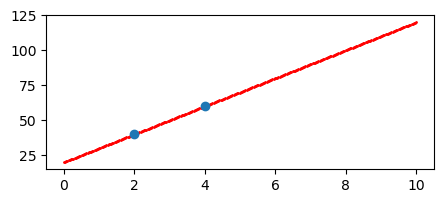

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 2)) # 현재 셀의 그래프 사이즈 조정
plt.rcParams['figure.figsize'] = (5, 2) # 지금부터 그래프 사이즈 조정
plt.scatter(x_, h, c='r', s=1) # 점그래프
plt.scatter(x, y)
plt.show()

In [54]:
np.linalg.solve(X, Y) # X가 정방행렬일 경우

array([[10.],
       [20.]])

## 6.2 단변량 회귀분석(선형 연립방정식) : 독립변수1, 데이터n개

In [58]:
import numpy as np
a = np.array([[2, 1], [3, 1], [4, 1], [5, 1]])
a # 정방행렬이 아님

array([[2, 1],
       [3, 1],
       [4, 1],
       [5, 1]])

In [62]:
# 역행렬(정방행렬일 때만 역행렬 가능)
#np.linalg.inv(a)

In [63]:
a.T # 전치행렬

array([[2, 3, 4, 5],
       [1, 1, 1, 1]])

In [64]:
a.T @ a # a가 정방행렬이 아니면 전치행렬을 곱하여 정방행렬을 만듦

array([[54, 14],
       [14,  4]])

In [66]:
np.linalg.inv(a.T @ a ) # a.T @ a의 역행렬

array([[ 0.2, -0.7],
       [-0.7,  2.7]])

In [67]:
np.linalg.inv(a.T @ a ) @ a.T @ a

array([[ 1.00000000e+00,  9.43689571e-16],
       [-2.22044605e-15,  1.00000000e+00]])

In [79]:
x = np.array([32, 64, 96, 118, 126, 144, 152.5, 158]) # 독립변수(입력데이터)
y = np.array([18, 24, 61.5, 49, 52, 105, 130.3, 125]) # 종속변수(타겟데이터)
X = np.column_stack( ( x, np.ones(len(x)) ) )
X = np.c_[x, np.ones(len(x))]
X = np.dstack( (x, np.ones(len(x))) ).reshape(-1, 2)
print(X)
Y = y[:, np.newaxis]
Y = y[:, None]
Y = np.expand_dims(y, axis=1)
Y = y.reshape(-1, 1)
print(Y)

[[ 32.    1. ]
 [ 64.    1. ]
 [ 96.    1. ]
 [118.    1. ]
 [126.    1. ]
 [144.    1. ]
 [152.5   1. ]
 [158.    1. ]]
[[ 18. ]
 [ 24. ]
 [ 61.5]
 [ 49. ]
 [ 52. ]
 [105. ]
 [130.3]
 [125. ]]


In [ ]:
#                            X @ wb = Y
#                    (X.T @ X) @ wb = X.T @ Y
#   X.T @ X의 역행렬 @ (X.T @ X) @ wb = X.T @ X의 역행렬 @ X.T @ Y
# [X.T @ X의 역행렬 @ (X.T @ X)] @ wb = X.T @ X의 역행렬 @ X.T @ Y
#                                 wb = X.T @ X의 역행렬 @ X.T @ Y

In [80]:
wb = np.linalg.inv(X.T@X) @ X.T @ Y
wb

array([[  0.87493126],
       [-26.79078617]])

In [81]:
h = wb[0]*x + wb[1] # 도출된 회귀식(y=w*x+b)으로 계산된 예측값

In [82]:
print('독립변수 :', x)
print('실제값 :', y)
print('예측값 :', h)

독립변수 : [ 32.   64.   96.  118.  126.  144.  152.5 158. ]
실제값 : [ 18.   24.   61.5  49.   52.  105.  130.3 125. ]
예측값 : [  1.20701424  29.20481464  57.20261504  76.45110282  83.45055292
  99.19931565 106.63623138 111.44835332]


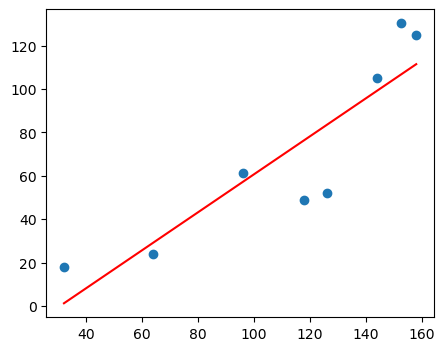

In [90]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))
# plt.rcParams['figure.figsize'] = (5, 2)
plt.scatter(x, y)
# plt.scatter(x, h, c='r') # 점그래프
plt.plot(x, h, c='r') # 선그래프

## 6.3 댜변량 회귀분석(선형 연립방정식) : 독립변수n, 데이터n개

In [92]:
x1 = np.array([60,65,55])
x2 = np.array([5.5, 5.0, 6.0])
x3 = np.array([1, 0, 1])
y = np.array([66,74,78])
X = np.column_stack( (x1, x2, x3))
X = np.c_[x1, x2, x3]
print(X)
Y = y.reshape(-1, 1) # y[:, np.newaxis]
print(Y)

[[60.   5.5  1. ]
 [65.   5.   0. ]
 [55.   6.   1. ]]
[[66]
 [74]
 [78]]


In [ ]:
#             X @ W = Y
# X의 역행렬 @ X @ W = X의 역행렬 @ Y
# W = X의 역행렬 @ Y

In [93]:
W = np.linalg.inv(X) @ Y
W

array([[ -0.4],
       [ 20. ],
       [-20. ]])

In [94]:
# 80Kg, 6.5ft, No(0)의 수명은?
80*W[0] + 6.5*W[1] + 0 *W[2]

array([98.])

# 7절. 연습문제
## 실습형

In [3]:
import numpy as np
from sklearn import datasets # sklearn 패키지(머신러닝 및 전처리)안의 datasets모듈을 load
iris = datasets.load_iris()
print(type(iris)) # 딕셔너리로부터 상속받은 타입
iris_data = iris.data
iris_data[0, :] # 0행만
iris_data[0, ...]
iris_data[0, ]
iris_data[0]

<class 'sklearn.utils._bunch.Bunch'>


array([5.1, 3.5, 1.4, 0.2])

In [107]:
print(iris.target) # 종속변수(타겟변수)
print(iris.target_names) # 종속변수가 뜻하는 종의 이름

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


In [114]:
# 인덱스 배열을 이용한 원 데이터의 종속변수
iris.target_names[iris.target][::50]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [4]:
# 실습형1. 각 변수별 평균 (열별 평균)
np.mean(iris_data, axis=0) # 열별 평균
iris_data.mean(axis=0)

array([5.84333333, 3.05733333, 3.758     , 1.19933333])

In [5]:
# 실습형2. 처음 다섯개 행출력
iris_data[:5] #iris_data[:5,], iris_data[:5,:] iris_data[:5,...]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [6]:
# 실습형3. 처음 다섯개 행에서 마지막 열을 제외한 나머지 열을 출력
ex3 = iris_data[:5, :-1]
ex3

array([[5.1, 3.5, 1.4],
       [4.9, 3. , 1.4],
       [4.7, 3.2, 1.3],
       [4.6, 3.1, 1.5],
       [5. , 3.6, 1.4]])

In [7]:
# 실습형 4. 처음 다섯개 행에서 마지막 열만 출력
ex4 = iris_data[:5,-1]
ex4

array([0.2, 0.2, 0.2, 0.2, 0.2])

In [8]:
# 실습형 5. 3번배열과 4번배열을 원래 모양으로 합하기
answer1 = np.c_[ex3, ex4]
answer2 = np.column_stack((ex3, ex4))
answer3 = np.hstack((ex3, ex4[:, np.newaxis]))
answer4 = np.hstack( (ex3, ex4.reshape(-1,1)))
answer5 = np.hstack( (ex3, np.expand_dims(ex4, axis=1)))
answer6 = np.concatenate( (ex3, ex4.reshape(-1, 1)), axis=1)
np.all(answer1==answer1)

True

In [9]:
def same_all(*answers):
    if len(answers)>0:
        first = answers[0]
        return all(np.all(first==answer) for answer in answers)
    else:
        return False

In [11]:
same_all(answer1, answer2, answer3, answer4, answer5, answer6)

True

In [13]:
# 실습형6. 처음 다섯 개 행을 이용해서 각 열 별로 평균보다 큰 값들만 출력
iris_sample = iris_data[:5]
print(iris_sample)
print('열별 평균 :',np.mean(iris_sample, axis = 0))
print('답:',iris_sample[iris_sample>np.mean(iris_sample, axis = 0)])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
열별 평균 : [4.86 3.28 1.4  0.2 ]
답: [5.1 3.5 4.9 1.5 5.  3.6]


In [15]:
col_mean = np.mean(iris_sample, axis=0)
for row in iris_sample:
    for 열, item in enumerate(row):
        print(item if item>col_mean[열] else None, end='\t')
    print()

5.1	3.5	None	None	
4.9	None	None	None	
None	None	None	None	
None	None	1.5	None	
5.0	3.6	None	None	


In [18]:
x = iris_sample.copy()
x[x<=x.mean(axis=0)] = None
x

array([[5.1, 3.5, nan, nan],
       [4.9, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, 1.5, nan],
       [5. , 3.6, nan, nan]])

In [20]:
# 위와 똑같은 걸 해 줌
np.where(iris_sample>iris_sample.mean(axis=0))

(array([0, 0, 1, 3, 4, 4], dtype=int64),
 array([0, 1, 0, 2, 0, 1], dtype=int64))

In [46]:
np.where(iris_sample>iris_sample.mean(axis=0),
        iris_sample,
        None)

array([[5.1, 3.5, None, None],
       [4.9, None, None, None],
       [None, None, None, None],
       [None, None, 1.5, None],
       [5.0, 3.6, None, None]], dtype=object)

In [44]:
# 메일 받은 내용
for idx in range(iris_sample.shape[1]):
    temp_ary = iris_sample[:, idx]
    values = temp_ary[temp_ary>temp_ary.mean()]
    print(f"{idx}열 : {temp_ary}에서 : {values}")
    

0열 : [5.1 4.9 4.7 4.6 5. ]에서 평균 4.859999999999999 : [5.1 4.9 5. ]
1열 : [3.5 3.  3.2 3.1 3.6]에서 평균 3.28 : [3.5 3.6]
2열 : [1.4 1.4 1.3 1.5 1.4]에서 평균 1.4 : [1.5]
3열 : [0.2 0.2 0.2 0.2 0.2]에서 평균 0.2 : []


## 문제풀이형

In [22]:
# 문제풀이형1. (3)
import numpy as np
a = np.arange(12).reshape(3,4)
a

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [26]:
print(a.sum(0), a.sum(axis=0), np.sum(a, axis=0), np.sum(a, 0)) # 열을 고정하고, 행들끼리 합 (열별합)

[12 15 18 21] [12 15 18 21] [12 15 18 21] [12 15 18 21]


In [30]:
# 문제풀이형2. (3)
#       나머지는 차원이 바뀐 값을 return하여 출력될 뿐 a가 바뀌지 않는다
import numpy as np
a = np.floor(10*np.random.random((3,4)))
print('(1)', a.ravel()) # (1) 차원 배열로 평평하게 펴주는 ravel() flatten() a가 바뀌지 않음
print('(2)', a.reshape(6,2))
print('(4)', a.T)
print('a는 변경없음 :', a)

(1) [9. 0. 0. 1. 8. 9. 4. 3. 1. 1. 2. 3.]
(2) [[9. 0.]
 [0. 1.]
 [8. 9.]
 [4. 3.]
 [1. 1.]
 [2. 3.]]
(4) [[9. 8. 1.]
 [0. 9. 1.]
 [0. 4. 2.]
 [1. 3. 3.]]
a는 변경없음 : [[9. 0. 0. 1.]
 [8. 9. 4. 3.]
 [1. 1. 2. 3.]]


In [31]:
# 문제풀이형2. (3) a배열 차원이 바뀜
a.resize((2,6)) # resize는 배열
a

array([[9., 0., 0., 1., 8., 9.],
       [4., 3., 1., 1., 2., 3.]])

In [32]:
# 문제풀이형3. (1)
import numpy as np
a = np.arange(12).reshape(3,4)
print(a)
a[:2]

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


array([[0, 1, 2, 3],
       [4, 5, 6, 7]])

In [34]:
# 문제풀이형 4. (2)
import numpy as np
a = np.array([1,2,3,4,5])
a[[1,3,4]] = 0
a

array([1, 0, 3, 0, 0])

In [35]:
# 문제풀이형5. (2)
a = np.array([1,2,3,4,5])
b = np.array([6,7,8,9,10])
answer1 = np.c_[a,b]
answer2 = np.column_stack( [a,b] )
answer3 = np.hstack((a[:, np.newaxis], b[:, np.newaxis]))
answer4 = np.stack([a,b], axis=1)
answer5 = np.stack([a,b], axis=-1)
answers = [answer1, answer2, answer3, answer4, answer5]
all(np.all(answer == answer1) for answer in answers)
same_all(*answers)

True